<a href="https://colab.research.google.com/github/A-Kester/csci-451/blob/main/docs/live-notebooks/52-attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Attention Mechanism

Scalable long-range dependencies in sequence models

## Motivation

[Last time](51-text-generation.qmd), we introduced a text-generation model containing a text embedding layer and a feedforward network composed of linear layers. This model was able to generally learn the idea that some tokens should be “near” other tokens, but wasn’t really able to capture the details of order or syntactic dependency in the text. Our model had a fixed context window, with each token inside the context window contributing equally to the prediction of the next token (and each token outside the window being completely irrelevant for prediction). This is somewhat unrealistic. For consider the snippet

*My cat is small, cute, and fluffy. **She** likes belly rubs.*

Suppose that we are trying to predict **She** from the preceding tokens. Intuitively, this prediction makes sense because **my cat** is a noun phrase in the previous sentence. However, the word **cat** is not immediately adjacent to **She**. A model like the feedforward model from last time could have **my cat** in context, but would treat everything else in context identically:

![](attachment:fig/token-context.png)

Here, all the tokens in the context window contribute equally to the prediction, including arguably irrelevant ones like **small** and **fluffy**. Our desired behavior looks more like this:

![](attachment:fig/token-context-2.png)

So, we are looking for a model architecture that can flexibly learn long-range dependencies between tokens. Although there are many approaches to this problem, in these notes we’ll use the one which has come to dominate multiple areas of modern deep learning, including language modeling – the attention mechanism.

## The Attention Mechanism

Schematically, we’d like to design an architecture in which:

-   Tokens can preferentially *attend* to other tokens within the context.
-   Tokens can depend in different *ways*, depending for example on semantics, syntax, or other relationships.

Here’s an example of how this might look with another simple, cat-themed example. Here, we’ve shown two different ways in which the tokens of the sentence *The cat sat on the mat* might attend to each other.

<figure id="fig-attention-diagrams">
<img src="attachment:fig/attention-heads.png" />
<figcaption>Figure 1: Schematic diagrams of two attention heads performing different functions. The first attention on the left picks up referential relationships between words, while the one on the right has been trained to detect rhyming words.</figcaption>
</figure>

Another useful way to view these relationships is as matrices:

<figure id="fig-attention-diagrams">
<img src="attachment:fig/attention-heads-2.png" />
<figcaption>Figure 2: The same attention heads as in <a href="#fig-attention-diagrams" class="quarto-xref">Figure 2</a>, visualized as matrices.</figcaption>
</figure>

Now we’ll formulate a model architecture that can learn these kinds of relationships.

### Attention Operates on Embedded Tokens

While it’s often helpful to visualize attention as operating on units of English text, there are actually two units of processing that have to take place before we can pass data to the attention mechanism. First, given a piece of text, we need to tokenize it to obtain a sequence $t_1, t_2, \ldots, t_n$ of tokens. Then, we need to *embed* these tokens into a vector space to obtain a sequence of vectors $\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n$. The attention mechanism operates on the embedded tokens $\mathbf{x}_i$. We can collect these vector into a matrix

$$
\begin{aligned}
    \mathbf{X}= \begin{bmatrix}
    - & \mathbf{x}_1^\top & -\\
    - &\mathbf{x}_2^\top & -\\
    & \vdots \\
    - & \mathbf{x}_n^\top & -
    \end{bmatrix} \in \mathbb{R}^{n \times d}\;,
\end{aligned}
$$

where $d$ is the dimension of the embedding space. The attention mechanism will take $\mathbf{U}$ as input and produce a new matrix $\mathbf{W}\in \mathbb{R}^{n \times d}$ as output, where the $i$-th row of $\mathbf{W}$ is a new vector representation of the $i$-th token that incorporates information about which *other* tokens in the sequence are relevant to it.

So, our attention mechanism is a trainable function from matrices of token embeddings $\mathbb{R}^{n \times d}$ to $\mathbb{R}^{n \times d}$:

$$
\text{Attn}: \mathbb{R}^{n \times d} \to \mathbb{R}^{n \times d}\;.
$$

### Fixed Attention

<span class="column-margin margin-aside">My exposition in this section is adapted from Bishop and Bishop (2023), Chapter 12.</span>

The simplest kind of map $\mathbb{R}^{n \times d} \to \mathbb{R}^{n \times d}$ would be a linear map:

$$
\begin{aligned}
    \mathbf{u}_j = \sum_{i=1}^n a_{ij} \mathbf{x}_i\;,
\end{aligned}
 \qquad(1)$$

In this expression, we would treat each coefficient $a_{ij}$ as a parameter that reflects how much the $i$th token in the sequence should contribute to the representation of the $j$th token. Now, it’s intuitive that (a) we shouldn’t be able to pay *negative* attention to a token and that (b) if I pay a lot of attention to one token, I must pay less attention others. These motivate the constraints that $a_{ij} \geq 0$ and $\sum_{i=1}^n a_{ij} = 1$ for all $j$.

### Self-Attention

<a href="#eq-attn-linear" class="quarto-xref">Equation 1</a> encodes some reasonable ideas, but it’s also limited – the attention weights $a_{ij}$ don’t depend on the inputs $\mathbf{w}_i$ at all. So, for example, we might have the fifth token attending strongly to the second token in every input sequence, *regardless of what those tokens are*. One way to address this problem is to *make the attention weights themselves depend on the input tokens*. Two tokens $i$ and $j$ are *similar* in the embedding space if $\mathbf{x}_i^\top \mathbf{x}_j$ is large. <span class="column-margin margin-aside">The concept of similarity being used here is unnormalized cosine similarity.</span> To make sure that the coefficients are nonnegative and sum to 1, we can pass them through a softmax:

$$
\begin{aligned}
    a_{ij} = \frac{e^{\mathbf{x}_i^\top \mathbf{x}_j}}{\sum_{j' = 1}^n e^{\mathbf{x}_i^\top \mathbf{x}_j'}}\;.
\end{aligned}
$$

If we let $\mathrm{SoftMax}: \mathbb{R}^{n\times p} \to \mathbb{R}^{n\times p}$ denote the softmax function applied row-wise to any $n\times p$ matrix for any $p$, then we can write the matrix of attention weights as

$$
\begin{aligned}
    \mathbf{A}= \mathrm{SoftMax}(\mathbf{X}\mathbf{X}^\top)\;,
\end{aligned}
$$

Our self-attention mechanism can then be written

$$
\begin{aligned}
    \mathbf{X}= \mathbf{A}\mathbf{X}= \mathrm{SoftMax}(\mathbf{X}\mathbf{X}^\top) \mathbf{X}\;.
\end{aligned}
 \qquad(2)$$

<a href="#eq-self-attn" class="quarto-xref">Equation 2</a> is an improvement in one way and a step back in another. On the one hand, we now have attention weights which depend on the input tokens. On the other, however, we have no more trainable model parameters!

### Key-Query-Value (KQV) Attention

To motivate the mechanism used in modern attention models, it’s helpful to introduce some terminology taken from the field of information retrieval. Suppose that you’d like to design a system that would allow users to browse a collection of books based on their preferences. Here’s how your system works:

-   The user inputs their preferences, represented as a vector, which we’ll call the *query* vector $\mathbf{q}\in \mathbb{R}^k$. For example, we might think of $q_1$ as describing how much action the user wants in their book, $q_2$ as describing how much romance they want, and so on.
-   Each book in the collection is also assigned a vector, which we’ll call the *key* vector $\mathbf{k}\in \mathbb{R}^k$. A book is a good match for the user’s preference when $\mathbf{q}^\top \mathbf{k}$ is large.
-   The book itself is the *value* returned by choosing the key $\mathbf{k}$ that best matches the query $\mathbf{q}$.

In our case, since we want an attention map $\text{Attn}: \mathbb{R}^{n \times d} \to \mathbb{R}^{n \times d}$, our values should be vectors $\mathbf{v}\in \mathbb{R}^d$ of the same dimension $d$ as the input token embeddings.

If we substitute the key-query-value mechanism into our attention formula, we get the following expression for the $j$-th output token representation:

$$
\begin{aligned}
    \mathbf{u}_j = \sum_{i=1}^n \frac{e^{\mathbf{q}_i^\top \mathbf{k}_j}}{\sum_{j' = 1}^n e^{\mathbf{q}_i^\top \mathbf{k}_{j'}}} \mathbf{v}_i\;,
\end{aligned}
$$

or, in matricized form,

$$
\begin{aligned}
    \mathbf{U}= \mathrm{SoftMax}(\mathbf{Q}\mathbf{K}^\top) \mathbf{V}\;,
\end{aligned}
 \qquad(3)$$

where $\mathbf{Q}, \mathbf{K}\in \mathbb{R}^{n \times k}$ are the matrices of query and key vectors, respectively, and $\mathbf{V}\in \mathbb{R}^{n \times d}$ is the matrix of value vectors.

It looks like we’ve lost the dependence on the input token embeddings $\mathbf{U}$ again, but we can fix this by making the query, key, and value vectors themselves depend on the input tokens. We do this by introducing *three* trainable linear maps $\mathbb{R}^d \to \mathbb{R}^k$ and $\mathbb{R}^d \to \mathbb{R}^d$ that take the input token embeddings $\mathbf{u}_i$ to the query, key, and value vectors $\mathbf{q}_i, \mathbf{k}_i, \mathbf{v}_i$:

$$
\begin{aligned}
    \mathbf{q}_i = \mathbf{W}_q \mathbf{x}_i\;,\quad
    \mathbf{k}_i = \mathbf{W}_k \mathbf{x}_i\;,\quad
    \mathbf{v}_i = \mathbf{W}_v \mathbf{x}_i\;,
\end{aligned}
$$

We can represent these maps in matrix form as $\mathbf{Q}= \mathbf{X}\mathbf{W}_q$, $\mathbf{K}= \mathbf{X}\mathbf{W}_k$, and $\mathbf{V}= \mathbf{X}\mathbf{W}_v$.

<a href="#eq-kqv-attn" class="quarto-xref">Equation 3</a> is *almost* the attention mechanism used in modern transformer models. It’s usually useful to add a scaling factor of $1/\sqrt{k}$ to the exponent in the softmax, which gives us the final formula for the attention mechanism:

$$
\begin{aligned}
    \mathbf{U}&= \mathrm{SoftMax}\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{k}}\right) \mathbf{V}\\
        \mathbf{Q}&= \mathbf{X}\mathbf{W}_q\;,\quad
        \mathbf{K}= \mathbf{X}\mathbf{W}_k\;,\quad
        \mathbf{V}= \mathbf{X}\mathbf{W}_v\;.
\end{aligned}
 \qquad(4)$$

The matrices $\mathbf{W}_q, \mathbf{W}_k, \mathbf{W}_v$ are the trainable parameters of the attention mechanism, and can be learned from data via optimization.

### An Attention Implementation

Here’s a simple implementation of the attention mechanism in PyTorch:

In [ ]:
from torch import nn
import torch
# TODO

We can use it like this:

In [ ]:
X = torch.randn(100, 16)  # Random embeddings for demonstration
embedding_dim = 16
key_dim = 8

# TODO

### Multi-Headed Attention

We can describe a single attention map $\text{Attn}: \mathbb{R}^{n \times d} \to \mathbb{R}^{n \times d}$ by its weight matrices $\mathbf{W}_q, \mathbf{W}_k, \mathbf{W}_v$. Learning these matrices allows the attention map to learn a set of dependency relationships between tokens. However, as in <a href="#fig-attention-diagrams" class="quarto-xref">Figure 2</a>, we might wish to learn to model *multiple* kinds of dependencies in sequences. To do this, we can simply concatenate multiple attention maps together. If $h$ is the number of attention *heads* that we want to learn, we can introduce $h$ different sets of weight matrices $\{\mathbf{W}_q^{(i)}, \mathbf{W}_k^{(i)}, \mathbf{W}_v^{(i)}\}_{i=1}^h$, which give us $h$ different attention maps $\text{Attn}^{(i)}: \mathbb{R}^{n \times d} \to \mathbb{R}^{n \times d}$ that operate in parallel on the same input. The outputs of these attention maps are then concatenated together and passed through a final linear map to produce the final output of the multi-head attention layer.

### From Attention to Transformers

Multiheaded attention is the primary ingredient behind the *transformer* architecture, which is the basis for modern language models. A transformer module combines multiple instances of multiheaded attention with feedforward layers and normalization layers. The final layers of the transformer model can be adapted to perform tasks including language generation, classification, and regression. It’s also possible to stack multiple transformer modules on top of each other to create deeper models.

<figure id="fig-transformer">
<img src="https://deeprevision.github.io/posts/001-transformer/transformer.png" />
<figcaption>Figure 3: Illustration of the transformer architecture. By <a href="https://deeprevision.github.io/posts/001-transformer/">Jean Nyandwi</a> and adapted from <span class="citation" data-cites="vaswani2017attention">Vaswani et al. (2017)</span>.</figcaption>
</figure>

## Multiheaded Attention in GPT2

Although training nontrivial attention and transformer models is typically quite computationally intensive, we can still get a sense for the workings of an attention model by looking at the learned attention weights of a pretrained model, such as GPT2.

<span class="column-margin margin-aside">*Many components in this section are adapted from [Prof. Michael Linderman’s lecture](https://middcs.github.io/data-science-notes/source/32-generative-nn.html) on generative language models*</span>

In [1]:
import torch
# Install needed packages iff running in Google Colab
import sys
if "google.colab" in sys.modules:
    !pip install bertviz torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 1.8 MB/s eta 0:00:00


We can access both the tokenizer and model for GPT2 using the HuggingFace `transformers` library.

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
checkpoint = "openai-community/gpt2"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
# Use slower eager attention to enable attention outputs
model = AutoModelForCausalLM.from_pretrained(checkpoint, attn_implementation="eager", output_attentions=True)
model.eval();  # Put model in evaluation mode rather than training mode

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

This is the largest model that we’ve looked at to date:

In [3]:
from torchinfo import summary
summary(model, depth = 3)

Layer (type:depth-idx)                             Param #
GPT2LMHeadModel                                    --
├─GPT2Model: 1-1                                   --
│    └─Embedding: 2-1                              38,597,376
│    └─Embedding: 2-2                              786,432
│    └─Dropout: 2-3                                --
│    └─ModuleList: 2-4                             --
│    │    └─GPT2Block: 3-1                         7,087,872
│    │    └─GPT2Block: 3-2                         7,087,872
│    │    └─GPT2Block: 3-3                         7,087,872
│    │    └─GPT2Block: 3-4                         7,087,872
│    │    └─GPT2Block: 3-5                         7,087,872
│    │    └─GPT2Block: 3-6                         7,087,872
│    │    └─GPT2Block: 3-7                         7,087,872
│    │    └─GPT2Block: 3-8                         7,087,872
│    │    └─GPT2Block: 3-9                         7,087,872
│    │    └─GPT2Block: 3-10                        7,08

Each of the 12 `GPT2Block`s in this model contain an implementation of the transformer architecture described in <a href="#fig-transformer" class="quarto-xref">Figure 3</a>, including a multiheaded attention layer. The following function definitions allow us to visualize the attention weights for a given input sequence.

In [4]:
from matplotlib import pyplot as plt
import seaborn as sns

def _format_special_chars(tokens):
    """Return sequence of tokens with special characters replaced"""
    return [t.replace('Ġ', ' ') for t in tokens]

def plot_attention(attentions, inputs, layer=0, head=0, **kwargs):
    """Plot the attentions attention weights, labeled with tokens, for a specific layer and head."""
    tokens = _format_special_chars(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]))
    att = attentions[layer][0, head, :, :].detach().numpy()
    ax = sns.heatmap(att, xticklabels=tokens, yticklabels=tokens, **kwargs)
    ax.set(title=f"Attentions Layer {layer} Head {head}", xlabel="Attends to", ylabel="Query")
    return ax

Let’s take a look, using the sample sentence with which we began the lecture:

<span class="column-margin margin-aside">This model has been specially configured so that the output obtained when we call `model` on a sequence of tokens is a tuple containing all the attention weights in every attention head and model layer.</span>

Figure 4: Example attention head from the GPT2 model, showing dependencies between tokens in the input sentence. The matrix being visualized is $$
\mathrm{SoftMax}\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{k}}\right)\;,
$$ from <a href="#eq-scaled-kqv-attn" class="quarto-xref">Equation 4</a>, the matrix of attention weights for the specified layer and head.

<Axes: title={'center': 'Attentions Layer 5 Head 10'}, xlabel='Attends to', ylabel='Query'>

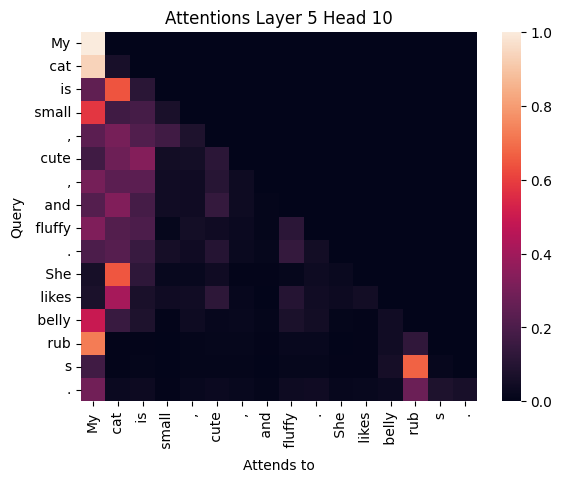

In [5]:
text = "My cat is small, cute, and fluffy. She likes belly rubs."
inputs = tokenizer(text, return_tensors="pt")
output = model(**inputs)
plot_attention(output.attentions, inputs, layer=5, head=10)

This particular attention head has learned several associations between tokens which appear reasonable:

-   The token **She** attends strongly to the token **cat**, which is a reasonable relationship given that **She** is a pronoun referring to **cat**.
-   **cat** attends to **My**, a modifier of possession.
-   The token **likes** also attends strongly to **cat**, the subject of the verb.
-   **s** attends to **rub**, since **s** is indeed the suffix in **rubs**.

It’s important to remember here that machine learning is always imperfect, and that examples like this are often cherry-picked for interest. Other attention heads are much less interesting:

Figure 5: A much less interesting attention head from the same model.

<Axes: title={'center': 'Attentions Layer 10 Head 1'}, xlabel='Attends to', ylabel='Query'>

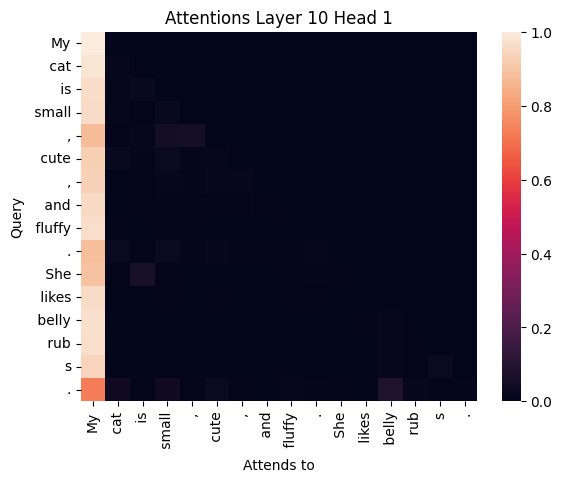

In [6]:
plot_attention(output.attentions, inputs, layer=10, head=1)

In this example, all the tokens in the sentence attend strongly to the very first token in the input.

## Quick Glimpse: Bias in Language Models

Examining attention weights can also give us some insight into the latent associations and biases learned by language models. Here’s an innocuous example:

Figure 6

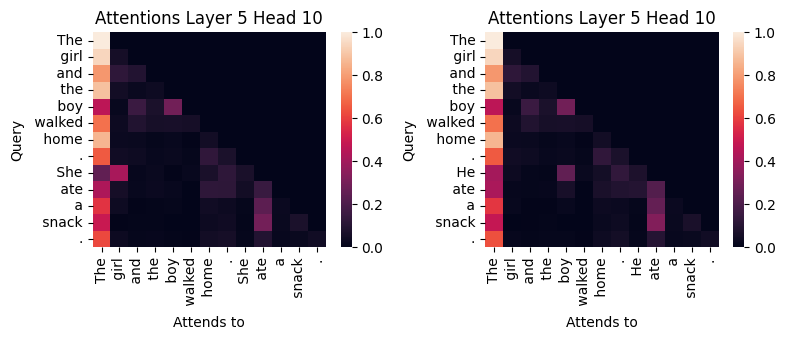

In [7]:
fig, axarr = plt.subplots(1, 2, figsize=(8, 3.5))
ax = axarr[0]

text = "The girl and the boy walked home. She ate a snack."
inputs = tokenizer(text, return_tensors="pt")
output = model(**inputs)
plot_attention(output.attentions, inputs, layer=5, head=10, ax=ax)

ax = axarr[1]

text = "The girl and the boy walked home. He ate a snack."
inputs = tokenizer(text, return_tensors="pt")
output = model(**inputs)
plot_attention(output.attentions, inputs, layer=5, head=10, ax=ax)

plt.tight_layout()

On the other hand, the same attention head has learned gendered associations which we may *not* wish to bake in to a language model:

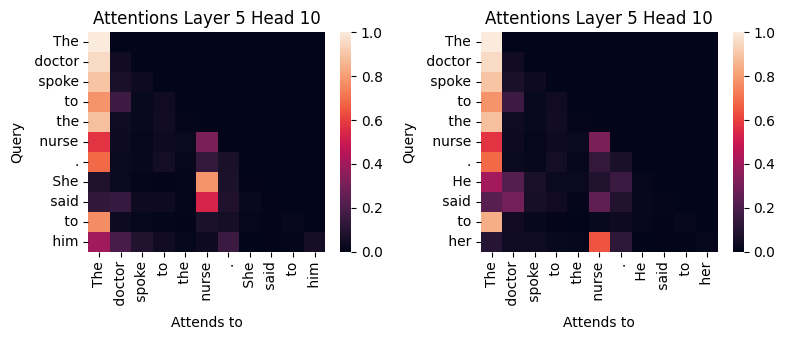

In [8]:
fig, axarr = plt.subplots(1, 2, figsize=(8, 3.5))
ax = axarr[0]

text = "The doctor spoke to the nurse. She said to him"
inputs = tokenizer(text, return_tensors="pt")
output = model(**inputs)
plot_attention(output.attentions, inputs, layer=5, head=10, ax=ax)

ax = axarr[1]

text = "The doctor spoke to the nurse. He said to her"
inputs = tokenizer(text, return_tensors="pt")
output = model(**inputs)
plot_attention(output.attentions, inputs, layer=5, head=10, ax=ax)

plt.tight_layout()

In this experiment, the model associates male gender pronouns to the token **doctor** and female gender pronouns to the token **nurse**, even when the text in question is ambiguous or arguably suggestive that the opposite association might be more appropriate.

Bishop, Christopher M, and Hugh Bishop. 2023. *Deep Learning: Foundations and Concepts*. Springer Nature.

Vaswani, Ashish, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N Gomez, Łukasz Kaiser, and Illia Polosukhin. 2017. “Attention Is All You Need.” *Advances In Neural Information Processing Systems* 30.